In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib

In [4]:
df = pd.read_csv("C:/Users/USER/Downloads/Breast_cancer_dataset.csv")

In [5]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
df.shape

(569, 33)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [8]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [9]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [10]:
df['diagnosis'].value_counts(normalize=True)

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

In [13]:
df = df.drop(columns=['id', 'Unnamed: 32'])
df.shape

(569, 31)

In [14]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


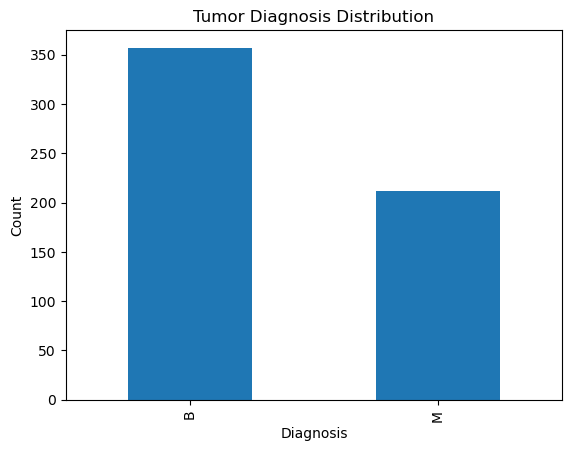

In [15]:
df['diagnosis'].value_counts().plot(kind='bar')

plt.title('Tumor Diagnosis Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

In [16]:
df.groupby('diagnosis')['radius_mean'].mean()

diagnosis
B    12.146524
M    17.462830
Name: radius_mean, dtype: float64

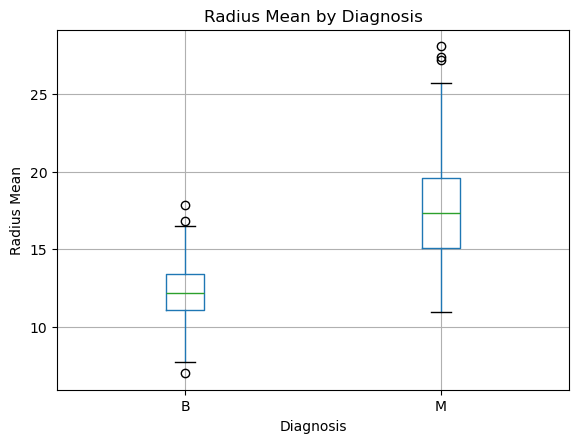

In [17]:
df.boxplot(column='radius_mean', by='diagnosis')

plt.title('Radius Mean by Diagnosis')
plt.suptitle('')
plt.xlabel('Diagnosis')
plt.ylabel('Radius Mean')
plt.show()

In [18]:
df.groupby('diagnosis').mean().T

diagnosis,B,M
radius_mean,12.146524,17.462830
texture_mean,17.914762,21.604906
perimeter_mean,78.075406,115.365377
area_mean,462.790196,978.376415
smoothness_mean,0.092478,0.102898
compactness_mean,0.080085,0.145188
concavity_mean,0.046058,0.160775
concave points_mean,0.025717,0.087990
symmetry_mean,0.174186,0.192909
fractal_dimension_mean,0.062867,0.062680


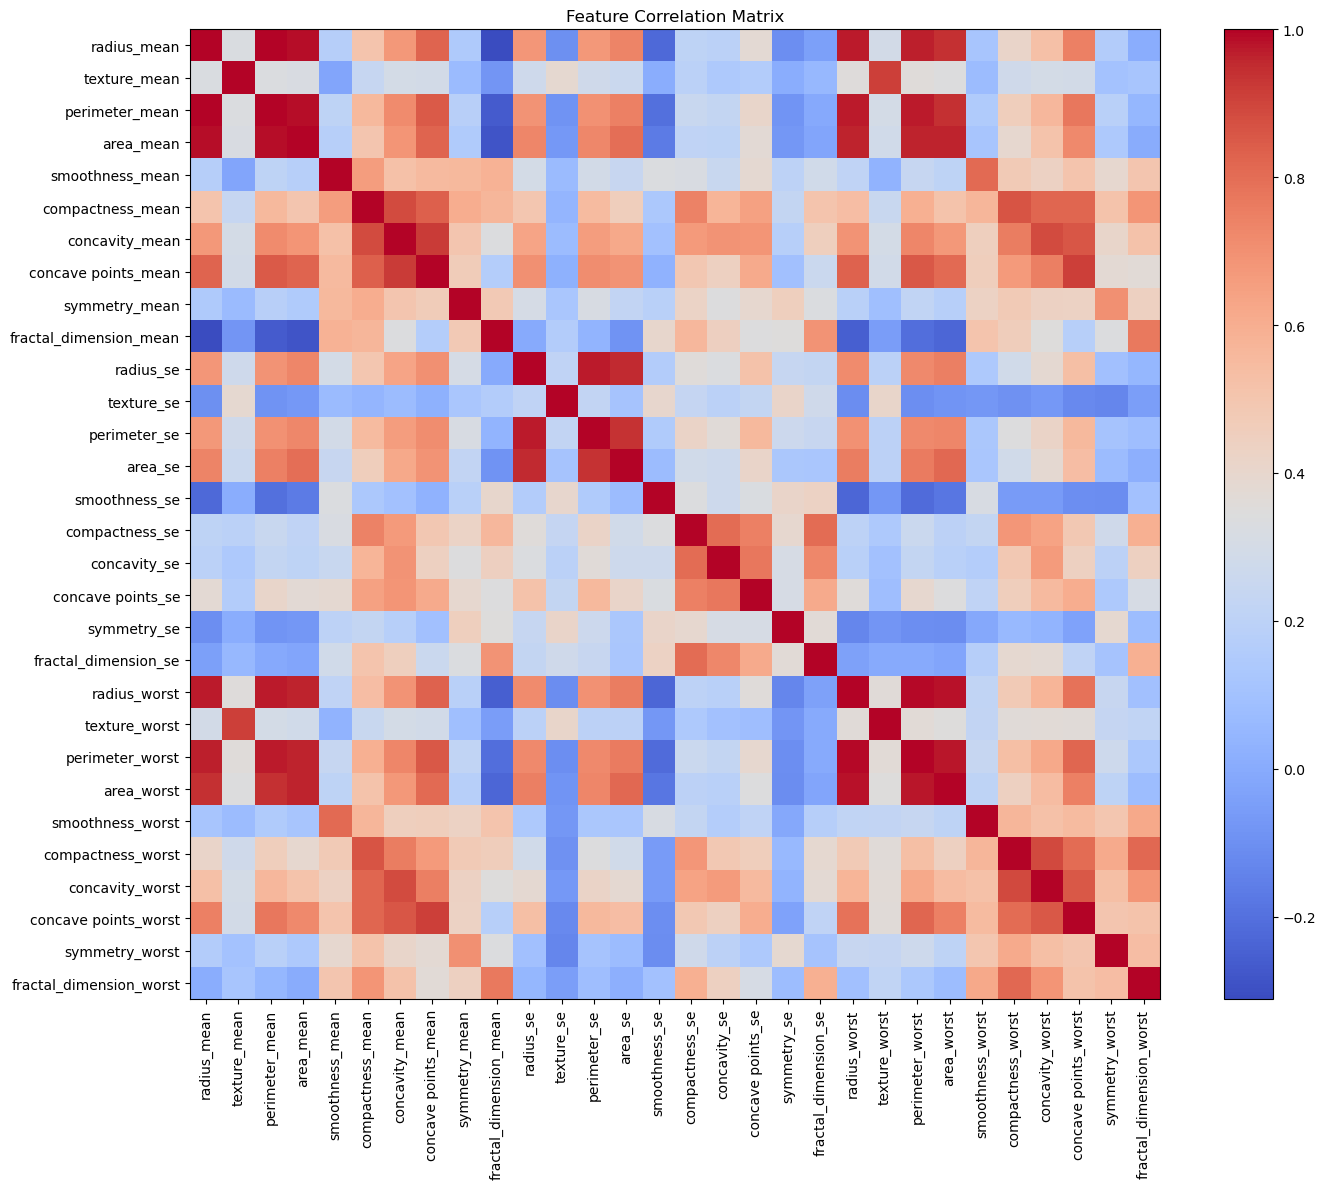

In [20]:
corr = df.drop(columns='diagnosis').corr()

plt.figure(figsize=(15,12))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

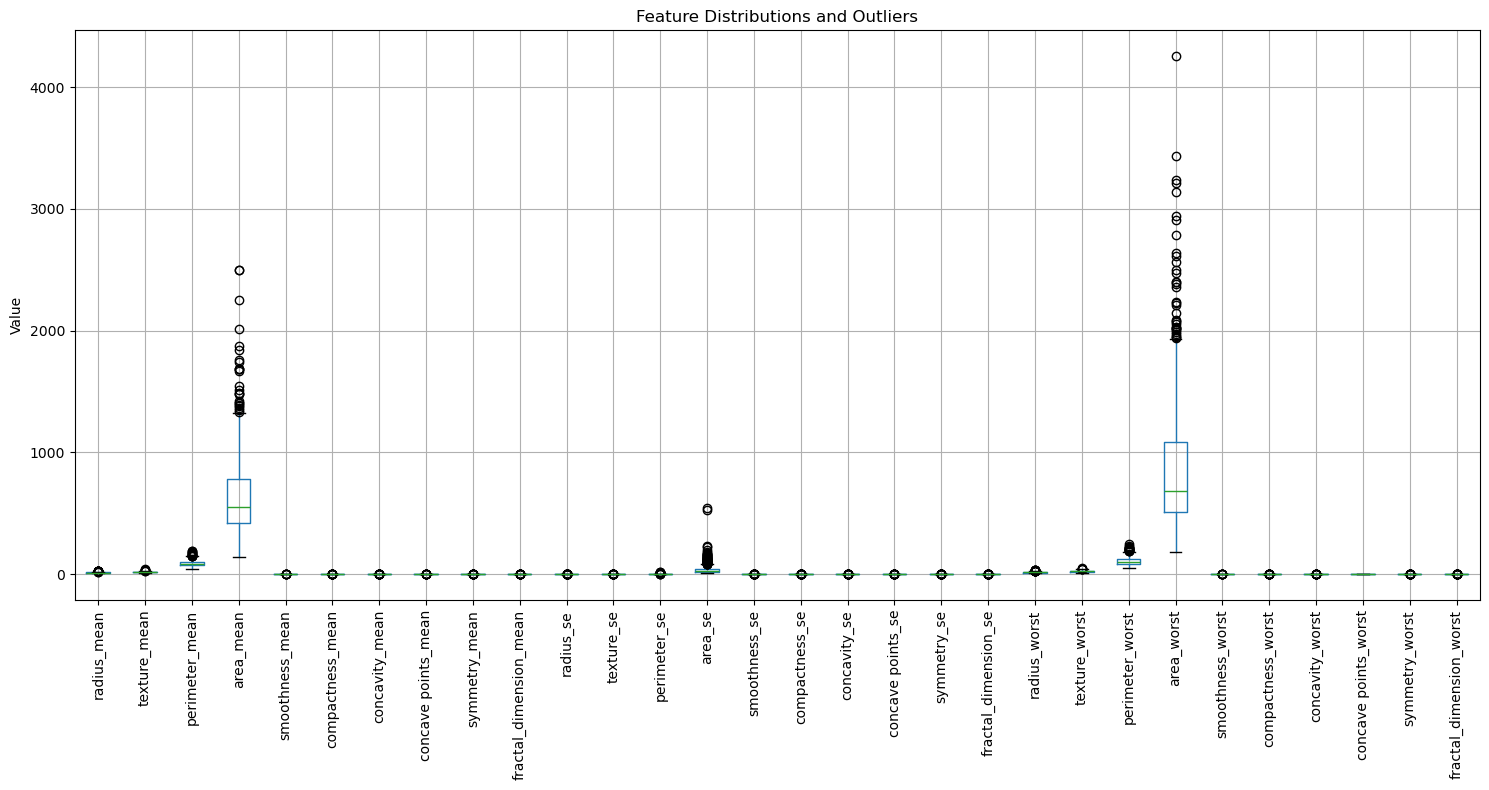

In [22]:
plt.figure(figsize=(15,8))

df.drop(columns='diagnosis').boxplot()

plt.xticks(rotation=90)
plt.title('Feature Distributions and Outliers')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

In [26]:
X = df.drop(columns='diagnosis')
y = df.diagnosis

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [30]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_encoded

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,

In [31]:
encoder.classes_

array(['B', 'M'], dtype=object)

In [32]:
y_encoded[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [33]:
pd.Series(y_encoded).value_counts()

0    357
1    212
Name: count, dtype: int64

In [43]:
X_train, X_test, y_encoded_train, y_encoded_test = train_test_split(
    X,
    y_encoded,
    random_state = 42,
    test_size = 0.2,
    stratify = y_encoded
)

In [41]:
print(X_train.shape)
print(X_test.shape)
print(y_encoded_train.shape)
print(y_encoded_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


The stratify keeps the proportion of y_encoded equal in both the training and test datasets.

In [44]:
print(pd.Series(y_encoded_train).value_counts())
print(pd.Series(y_encoded_test).value_counts())

0    285
1    170
Name: count, dtype: int64
0    72
1    42
Name: count, dtype: int64


In [48]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(type(X_train_scaled))
print(X_train_scaled.shape)
print(X_test_scaled.shape)

<class 'numpy.ndarray'>
(455, 30)
(114, 30)


In [55]:
model = LogisticRegression()
model.fit(X_train_scaled, y_encoded_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [56]:
y_pred = model.predict(X_test_scaled)

In [59]:
accuracy = accuracy_score(y_encoded_test, y_pred)
accuracy

0.9649122807017544

In [61]:
cm = confusion_matrix(y_encoded_test, y_pred)
cm

array([[71,  1],
       [ 3, 39]])

In [64]:
print(classification_report(y_encoded_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [70]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_encoded_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [72]:
y_knn_pred = knn.predict(X_test_scaled)
y_knn_pred

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1])

In [73]:
knn_accuracy = accuracy_score(y_encoded_test, y_knn_pred)
knn_accuracy

0.956140350877193

In [74]:
knn_cm = confusion_matrix(y_encoded_test, y_knn_pred)
knn_cm

array([[71,  1],
       [ 4, 38]])

In [75]:
print(classification_report(y_encoded_test, y_knn_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [78]:
dc = DecisionTreeClassifier()
dc.fit(X_train, y_encoded_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [79]:
y_dc_pred = dc.predict(X_test)
y_dc_pred

array([0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1])

In [80]:
dc_accuracy = accuracy_score(y_encoded_test, y_dc_pred)
dc_accuracy

0.9385964912280702

In [83]:
dc_cm = confusion_matrix(y_encoded_test, y_dc_pred)
dc_cm

array([[69,  3],
       [ 4, 38]])

In [81]:
print(classification_report(y_encoded_test, y_dc_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95        72
           1       0.93      0.90      0.92        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [87]:
cv_scores = cross_val_score(model, X_train_scaled, y_encoded_train, cv=5)
cv_scores

array([0.96703297, 0.98901099, 0.95604396, 0.97802198, 0.96703297])

In [88]:
cv_scores.mean()

np.float64(0.9714285714285715)

In [90]:
param_grid = {
    'n_neighbors' : [3,5,7,9,11,13,15]
}

In [91]:
grid_search = GridSearchCV(
    knn,
    param_grid,
    cv=5
)
grid_search.fit(X_train_scaled, y_encoded_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


In [92]:
grid_search.best_params_

{'n_neighbors': 3}

In [94]:
y_knn_tuned_pred = grid_search.predict(X_test_scaled)

In [95]:
knn_tuned_accuracy = accuracy_score(y_encoded_test, y_knn_tuned_pred)
knn_tuned_accuracy

0.9385964912280702

In [96]:
knn_tuned_cm = confusion_matrix(y_encoded_test, y_knn_tuned_pred)
knn_tuned_cm

array([[71,  1],
       [ 6, 36]])

In [98]:
rf = RandomForestClassifier()
rf.fit(X_train, y_encoded_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [99]:
y_rf_pred = rf.predict(X_test)

In [100]:
rf_accuracy = accuracy_score(y_encoded_test, y_rf_pred)
rf_accuracy

0.9649122807017544

In [101]:
rf_cm = confusion_matrix(y_encoded_test, y_rf_pred)
rf_cm

array([[72,  0],
       [ 4, 38]])

In [102]:
print(classification_report(y_encoded_test, y_rf_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [104]:
rf_cv_scores = cross_val_score(
    rf, X_train, y_encoded_train, cv=5
)
rf_cv_scores

array([0.98901099, 0.98901099, 0.92307692, 0.95604396, 0.92307692])

In [105]:
rf_cv_scores.mean()

np.float64(0.9560439560439562)

In [107]:
rf_param_grid = { 'n_estimators': [50,100,150,200] }

In [108]:
rf_grid_search = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5
)
rf_grid_search.fit(X_train,y_encoded_train)

,estimator,RandomForestClassifier()
,param_grid,"{'n_estimators': [50, 100, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [109]:
rf_grid_search.best_params_

{'n_estimators': 100}

In [111]:
y_rf_tuned_pred = rf_grid_search.predict(X_test)

In [112]:
rf_tuned_accuracy = accuracy_score(y_encoded_test,y_rf_tuned_pred)
rf_tuned_accuracy

0.9736842105263158

In [113]:
rf_tuned_cm = confusion_matrix(y_encoded_test, y_rf_tuned_pred)
rf_tuned_cm

array([[72,  0],
       [ 3, 39]])

In [114]:
print(classification_report(y_encoded_test, y_rf_tuned_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [115]:
rf_tuned_cv_scores = cross_val_score(
    rf_grid_search.best_estimator_,
    X_train,
    y_encoded_train,
    cv=5
)

rf_tuned_cv_scores

array([0.98901099, 0.98901099, 0.92307692, 0.96703297, 0.91208791])

In [116]:
rf_tuned_cv_scores.mean()

np.float64(0.9560439560439562)

In [119]:
rf_recall_grid_search = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring = 'recall'
)
rf_recall_grid_search.fit(X_train, y_encoded_train)

,estimator,RandomForestClassifier()
,param_grid,"{'n_estimators': [50, 100, ...]}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [120]:
rf_recall_grid_search.best_params_

{'n_estimators': 50}

In [122]:
y_rf_recall_pred = rf_recall_grid_search.predict(X_test)

In [123]:
rf_recall_accuracy = accuracy_score(y_encoded_test, y_rf_recall_pred)
rf_recall_accuracy

0.9649122807017544

In [124]:
rf_recall_cm = confusion_matrix(y_encoded_test, y_rf_recall_pred)
rf_recall_cm

array([[72,  0],
       [ 4, 38]])

In [125]:
print(classification_report(y_encoded_test, y_rf_recall_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [126]:
rf = RandomForestClassifier(random_state=42)

In [127]:
rf_param_grid = {
    'n_estimators': [50, 100 ,150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

In [133]:
rf_grid_search = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring = 'recall'
)

rf_grid_search.fit(X_train, y_encoded_train)
print('done')

done


In [134]:
rf_grid_search.best_params_

{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 50}

In [140]:
y_rf_tuned_pred = rf_grid_search.predict(X_test)

In [141]:
rf_accuracy = accuracy_score(y_encoded_test, y_rf_tuned_pred)
rf_accuracy

0.9736842105263158

In [142]:
rf_cm = confusion_matrix(y_encoded_test, y_rf_tuned_pred)
rf_cm

array([[72,  0],
       [ 3, 39]])

In [143]:
print(classification_report(y_encoded_test, y_rf_tuned_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [144]:
feature_importance = rf_grid_search.best_estimator_.feature_importances_
feature_importance

array([0.06278239, 0.01292489, 0.08305071, 0.04882389, 0.00548797,
       0.01907566, 0.04807175, 0.10419401, 0.0037467 , 0.00482512,
       0.02339443, 0.00566235, 0.01584916, 0.03997748, 0.00316534,
       0.00590695, 0.00527207, 0.00352257, 0.00451395, 0.00620856,
       0.09943691, 0.01471086, 0.07748236, 0.10290593, 0.01174299,
       0.01788123, 0.04611848, 0.10999229, 0.00918425, 0.00408876])

In [145]:
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': feature_importance
})
feature_importance_df

,feature,importance
0,radius_mean,0.062782
1,texture_mean,0.012925
2,perimeter_mean,0.083051
3,area_mean,0.048824
4,smoothness_mean,0.005488
5,compactness_mean,0.019076
6,concavity_mean,0.048072
7,concave points_mean,0.104194
8,symmetry_mean,0.003747
9,fractal_dimension_mean,0.004825


In [149]:
feature_importance_df = feature_importance_df.sort_values(
    ascending=False,
    by='importance'
)
feature_importance_df

,feature,importance
27,concave points_worst,0.109992
7,concave points_mean,0.104194
23,area_worst,0.102906
20,radius_worst,0.099437
2,perimeter_mean,0.083051
22,perimeter_worst,0.077482
0,radius_mean,0.062782
3,area_mean,0.048824
6,concavity_mean,0.048072
26,concavity_worst,0.046118


In [151]:
top_features = feature_importance_df.head(10)
top_features

,feature,importance
27,concave points_worst,0.109992
7,concave points_mean,0.104194
23,area_worst,0.102906
20,radius_worst,0.099437
2,perimeter_mean,0.083051
22,perimeter_worst,0.077482
0,radius_mean,0.062782
3,area_mean,0.048824
6,concavity_mean,0.048072
26,concavity_worst,0.046118


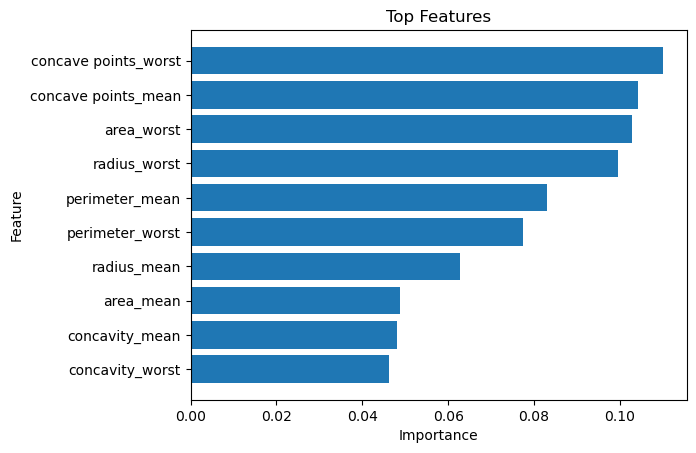

In [157]:
plt.barh(top_features.feature, top_features.importance)
plt.title('Top Features')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.ylabel('Feature')
plt.show()

In [158]:
y_rf_prob = rf_grid_search.predict_proba(X_test)
y_rf_prob

array([[0.98, 0.02],
       [0.  , 1.  ],
       [0.66, 0.34],
       [0.38, 0.62],
       [0.92, 0.08],
       [0.98, 0.02],
       [0.22, 0.78],
       [0.86, 0.14],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.02, 0.98],
       [0.98, 0.02],
       [0.  , 1.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.9 , 0.1 ],
       [0.98, 0.02],
       [0.82, 0.18],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [0.02, 0.98],
       [0.76, 0.24],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.46, 0.54],
       [0.04, 0.96],
       [0.  , 1.  ],
       [0.  , 1.  ],
       [0.98, 0.02],
       [0.  , 1.  ],
       [0.06, 0.94],
       [0.94, 0.06],
       [0.94, 0.06],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.1 , 0.9 ],
       [0.82, 0.18],
       [0.66, 0.34],
       [1.  , 0.  ],
       [0.74, 0.26],
       [1.  , 0.  ],
       [0.92, 0.08],
       [0.12, 0.88],
       [0.96, 0.04],
       [0.2 ,

In [160]:
y_rf_prob_malignant = y_rf_prob[:, 1]
y_rf_prob_malignant

array([0.02, 1.  , 0.34, 0.62, 0.08, 0.02, 0.78, 0.14, 0.  , 0.  , 0.98,
       0.02, 1.  , 0.  , 0.  , 0.  , 0.1 , 0.02, 0.18, 0.  , 0.  , 0.  ,
       1.  , 0.98, 0.24, 0.  , 0.  , 0.54, 0.96, 1.  , 1.  , 0.02, 1.  ,
       0.94, 0.06, 0.06, 0.  , 0.  , 0.9 , 0.18, 0.34, 0.  , 0.26, 0.  ,
       0.08, 0.88, 0.04, 0.8 , 0.  , 0.02, 1.  , 1.  , 0.04, 0.  , 0.02,
       0.84, 0.04, 0.  , 0.  , 0.98, 0.04, 0.06, 0.88, 0.  , 0.2 , 0.  ,
       0.96, 1.  , 0.  , 0.8 , 0.  , 1.  , 0.94, 0.  , 0.  , 0.32, 0.  ,
       1.  , 0.02, 0.88, 1.  , 1.  , 0.  , 0.  , 0.  , 0.02, 1.  , 0.8 ,
       1.  , 0.  , 1.  , 0.  , 0.48, 0.  , 0.2 , 0.02, 0.06, 0.88, 0.  ,
       0.  , 0.  , 0.  , 0.08, 0.  , 0.  , 0.02, 1.  , 0.08, 1.  , 0.  ,
       0.02, 0.14, 0.56, 0.98])

In [163]:
fpr, tpr, thresholds = roc_curve(
    y_encoded_test,
    y_rf_prob_malignant
)
print('FPR: ', fpr)
print('TPR:', tpr)
print('Thresholds:', thresholds)

FPR:  [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.01388889 0.04166667 0.05555556
 0.05555556 0.13888889 0.13888889 0.30555556 0.47222222 1.        ]
TPR: [0.         0.42857143 0.52380952 0.61904762 0.64285714 0.73809524
 0.76190476 0.83333333 0.92857143 0.92857143 0.92857143 0.92857143
 0.97619048 0.97619048 1.         1.         1.         1.        ]
Thresholds: [ inf 1.   0.98 0.94 0.9  0.88 0.84 0.8  0.54 0.48 0.34 0.32 0.24 0.14
 0.1  0.04 0.02 0.  ]


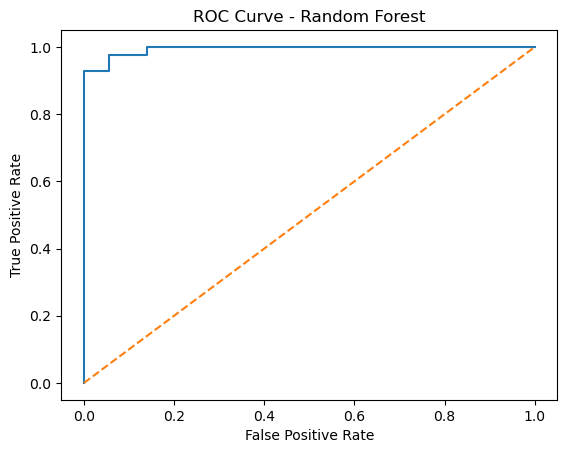

In [165]:
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.show()

In [168]:
auc = roc_auc_score(y_encoded_test, y_rf_prob_malignant)
auc

0.9940476190476191

In [170]:
final_model = rf_grid_search.best_estimator_

In [171]:
final_model.predict(X_test)

array([0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1])

In [172]:
(final_model.predict(X_test) == y_rf_tuned_pred).all()

np.True_

In [176]:
feature_names = X.columns.tolist()
feature_names

['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']

In [177]:
joblib.dump(final_model, 'breast_cancer_model.pkl')

['breast_cancer_model.pkl']

In [178]:
joblib.load('breast_cancer_model.pkl')

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False
